In [4]:
# Продолжайте развивать генератор данных.
# Решите задачу трекинга объектов.
# Этап 1. Генератор последовательности кадров с потоком клеток, перемещающихся "слева - направо".
#  - сгенерировать последовательность кадров в 10 секунд (итого - примерно 240 кдаров)
# - первичное положение клеток - случайный пиксель
# - при достижении границы изображения объект прекращает свое существование
# - пусть генератор пути клеток позволяет перемещать клетку по синусоиде  y(x(t) ) = ax+b + c * sin( omega *x) + eps_noise 
# - a,b,c omega - случайно сгенерированные значения для данной клетки  eps_noise - случайное значение для каждой секунды
# - a,b,c omega - случайно сгенерированные значения для данной клетки
# - 10 секунду - 10 отсчетов времени t,  положение между кажром 0 и кадром 24 интерполируется при помощи линейной интерполяции по формуле: 
# - выполнить то же самое, только зависимость не T(z),как в примере, а y(x)

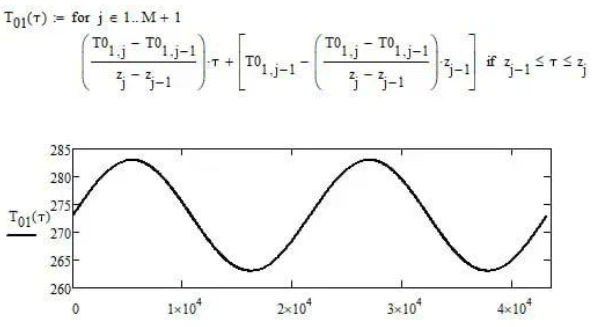

In [ ]:
# Этап 2. Трекинг объектов.
# Используя пример, приведенный в лекции про трекинг, решить задачу трекинга объектов
# Пути (положения) объктов на каждом кадре сохранить в файл.
# Визуализировать траектории объектов на изображении.

In [2]:
import numpy as np
import cv2
import random
from IPython.display import display, Video
import os
import glob
import matplotlib.pyplot as plt
from tqdm import tqdm

class CellTrackingGenerator:
    def __init__(self, num_cells=5, video_size=(512, 512), num_frames=240, fon_path="", patch_path="", output_path="cells.mp4"):
        self.num_cells = num_cells
        self.video_size = video_size
        self.num_frames = num_frames
        self.fon_path = fon_path
        self.patch_path = patch_path
        self.output_path = output_path

        self.fon_images = glob.glob(os.path.join(fon_path, "*.png"))
        self.patch_images = glob.glob(os.path.join(patch_path, "*.png"))

        if not self.fon_images:
            raise ValueError(f"Фоны не найдены: {fon_path}")
        if not self.patch_images:
            raise ValueError(f"Патчи не найдены: {patch_path}")

        self.background = cv2.imread(random.choice(self.fon_images))
        self.background = cv2.resize(self.background, self.video_size)

        self.patch = cv2.imread(random.choice(self.patch_images), cv2.IMREAD_UNCHANGED)
        if self.patch.shape[2] == 4:
            self.patch_alpha = self.patch[:, :, 3] / 255.0
            self.patch = self.patch[:, :, :3]
        else:
            self.patch_alpha = np.ones(self.patch.shape[:2], dtype=np.float32)

        self.params = []
        for _ in range(num_cells):
            a = random.uniform(-1, 1)
            b = random.uniform(0, self.video_size[1])
            c = random.uniform(-10, 10)
            omega = random.uniform(0.1, 1)
            self.params.append((a, b, c, omega))

        self.positions = [(0, random.randint(0, self.video_size[1] - 1) + i * 20) for i in range(num_cells)]
        self.trajectories = [[] for _ in range(num_cells)]

    def overlay_patch_on_background(self, background, patch, alpha, x_offset, y_offset):
        h, w = patch.shape[:2]
        h = min(h, background.shape[0] - y_offset)
        w = min(w, background.shape[1] - x_offset)
        for c in range(3):
            background[y_offset:y_offset+h, x_offset:x_offset+w, c] = (
                (1.0 - alpha[:h, :w]) * background[y_offset:y_offset+h, x_offset:x_offset+w, c] +
                alpha[:h, :w] * patch[:h, :w, c]
            )
        return background

    def generate(self):
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(self.output_path, fourcc, 30, self.video_size)

        for t in range(self.num_frames):
            frame = self.background.copy()
            for idx, (x, y) in enumerate(self.positions):
                a, b, c, omega = self.params[idx]
                noise = random.uniform(-5, 5)
                x_t = t * (self.video_size[0] - 1) / self.num_frames
                y_t = int(a * x_t + b + c * np.sin(omega * x_t) + noise)
                y_t = np.clip(y_t, 0, self.video_size[1] - 1)

                self.positions[idx] = (x_t, y_t)
                self.trajectories[idx].append((x_t, y_t))

                frame = self.overlay_patch_on_background(frame, self.patch, self.patch_alpha, int(x_t), y_t)

            out.write(frame)

        out.release()
        print(f"Видео сохранено: {self.output_path}")


# Трекинг 
class SimpleTracker:
    def __init__(self):
        self.tracks = {}
        self.next_id = 0

    def update(self, detections):
        if not self.tracks:
            for det in detections:
                self.tracks[self.next_id] = {'positions': [self._center(det)], 'missed': 0}
                self.next_id += 1
            return self.tracks

        matched_det = set()
        updated_tracks = {}

        for track_id, track in self.tracks.items():
            last_pos = track['positions'][-1]
            min_dist = float('inf')
            best_match = None

            for i, det in enumerate(detections):
                if i in matched_det:
                    continue
                dist = self._distance(last_pos, self._center(det))
                if dist < 25:
                    if dist < min_dist:
                        min_dist = dist
                        best_match = i

            if best_match is not None:
                matched_det.add(best_match)
                track['positions'].append(self._center(detections[best_match]))
                track['missed'] = 0
                updated_tracks[track_id] = track

        for i, det in enumerate(detections):
            if i not in matched_det:
                self.tracks[self.next_id] = {'positions': [self._center(det)], 'missed': 0}
                self.next_id += 1

        return self.tracks

    def _center(self, bbox):
        x, y, w, h = bbox
        return (x + w // 2, y + h // 2)

    def _distance(self, p1, p2):
        return np.linalg.norm(np.array(p1) - np.array(p2))


class BloodCellTracker:
    def __init__(self, video_path,
                 output_video_path="output/tracked_cells.mp4",
                 raw_video_path="output/raw_cells.mp4"):
        self.cap = cv2.VideoCapture(video_path)
        if not self.cap.isOpened():
            raise ValueError(f"Не удалось открыть видео: {video_path}")

        self.output_video_path = output_video_path
        self.raw_video_path = raw_video_path

        self.frame_width = int(self.cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        self.frame_height = int(self.cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        self.fps = int(self.cap.get(cv2.CAP_PROP_FPS))
        self.total_frames = int(self.cap.get(cv2.CAP_PROP_FRAME_COUNT))

        self.MIN_CELL_AREA = 100
        self.MAX_CELL_AREA = 3000
        self.THRESHOLD = 15
        self.MIN_DISTANCE = 50
        self.MIN_ASPECT_RATIO = 1.0
        self.MAX_ASPECT_RATIO = 2.5

        self.kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        self.tracker = SimpleTracker()
        self.track_history = {}
        self.colors = np.random.randint(0, 255, (1000, 3))

        os.makedirs(os.path.dirname(self.output_video_path), exist_ok=True)

        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        self.out_writer = cv2.VideoWriter(self.output_video_path, fourcc, self.fps, (self.frame_width, self.frame_height))
        self.raw_writer = cv2.VideoWriter(self.raw_video_path, fourcc, self.fps, (self.frame_width, self.frame_height))

    def preprocess_frame(self, frame):
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        gray = hsv[:, :, 1]
        blurred = cv2.GaussianBlur(gray, (9, 9), 0)
        thresh = cv2.adaptiveThreshold(blurred, 255,
                                       cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY_INV, 11, 2)
        morphed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, self.kernel)
        morphed = cv2.morphologyEx(morphed, cv2.MORPH_OPEN, self.kernel)
        return morphed

    def detect_cells(self, frame):
        mask = self.preprocess_frame(frame)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        valid_boxes = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            perimeter = cv2.arcLength(cnt, True)
            circularity = 4 * np.pi * area / (perimeter ** 2) if perimeter > 0 else 0

            if (self.MIN_CELL_AREA < area < self.MAX_CELL_AREA and
                0.7 < circularity < 1.3):
                x, y, w, h = cv2.boundingRect(cnt)
                aspect_ratio = max(w, h) / min(w, h)
                if self.MIN_ASPECT_RATIO < aspect_ratio < self.MAX_ASPECT_RATIO:
                    valid_boxes.append((x, y, w, h))

        return valid_boxes

    def update_tracking(self, detections):
        tracks = self.tracker.update(detections)
        self.track_history = {
            track_id: data['positions']
            for track_id, data in tracks.items()
            if data['missed'] < 5
        }

    def visualize(self, frame, save_writer=None):
        display_frame = frame.copy()

        for track_id, positions in self.track_history.items():
            color = self.colors[track_id % len(self.colors)].tolist()
    
            if len(positions) > 1:
                for i in range(1, len(positions)):
                    cv2.line(display_frame, positions[i - 1], positions[i], color, 2)
    
            if positions:
                x, y = positions[-1]
                cv2.circle(display_frame, (x, y), 5, color, -1)
                cv2.putText(display_frame, f"ID:{track_id}", (x + 10, y),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    
        # Сохраняем кадр в видео, если передан writer
        if save_writer is not None:
            save_writer.write(display_frame)
    
        # Показываем
        cv2.imshow('Cell Tracking', display_frame)
        cv2.waitKey(1)

        return display_frame  # Важно: возвращаем кадр, чтобы использовать в .write()

    def save_results(self, output_dir='output'):
        os.makedirs(output_dir, exist_ok=True)
        with open(os.path.join(output_dir, 'tracks.csv'), 'w') as f:
            f.write("track_id,frame,x,y\n")
            for track_id, positions in self.track_history.items():
                for frame_num, (x, y) in enumerate(positions):
                    f.write(f"{track_id},{frame_num},{x},{y}\n")

        plt.figure(figsize=(10, 10))
        has_labels = False  # <- добавили флаг
        for track_id, positions in self.track_history.items():
            if len(positions) > 1:
                xs, ys = zip(*positions)
                plt.plot(xs, ys, label=f'Track {track_id}')
                has_labels = True
        
        plt.gca().invert_yaxis()
        if has_labels:
            plt.legend()
        else:
            print("⚠️ Нет треков для отображения легенды.")
        plt.title("Cell Trajectories")
        plt.savefig(os.path.join(output_dir, 'trajectories.png'))
        plt.close()

    def run(self):
        from tqdm import tqdm
        with tqdm(total=self.total_frames, desc="Tracking cells") as pbar:
            while True:
                ret, frame = self.cap.read()
                if not ret:
                    break

                try:
                    detections = self.detect_cells(frame)
                    self.update_tracking(detections)

                    visual_frame = self.visualize(frame)

                    self.out_writer.write(visual_frame)  # Видео с траекториями
                    self.raw_writer.write(frame)         # Оригинал без траекторий

                    cv2.imshow('Cell Tracking', visual_frame)
                    if cv2.waitKey(1) == 27:
                        break

                    pbar.update(1)
                except Exception as e:
                    print(f"Ошибка обработки кадра: {e}")
                    break

        self.cap.release()
        self.out_writer.release()
        self.raw_writer.release()
        cv2.destroyAllWindows()
        self.save_results()


if __name__ == "__main__":
    fon_path = "/Users/zuhroabdulloeva/Desktop/4 КУРС/cv/blood_cells_dataset/fon/"  
    patch_path = "/Users/zuhroabdulloeva/Desktop/4 КУРС/cv/blood_cells_dataset/patch/"  
    video_output = "cells.mp4"

    generator = CellTrackingGenerator(fon_path=fon_path, patch_path=patch_path, output_path=video_output)
    generator.generate()

    tracker = BloodCellTracker(video_output)
    tracker.run()

Видео сохранено: cells.mp4


2025-04-05 07:21:02.444 Python[16534:1798828] +[IMKClient subclass]: chose IMKClient_Modern
2025-04-05 07:21:02.444 Python[16534:1798828] +[IMKInputSession subclass]: chose IMKInputSession_Modern
Tracking cells: 100%|█████████████████████████| 240/240 [00:07<00:00, 30.46it/s]
